Finite-horizon mixed-noise observer: sigma_repr=0.25, tau_exec=0.025
t= 1: lower_L=-0.732, upper_L= 0.732, lower_b= 0.156, upper_b= 0.844
t= 2: lower_L=-0.724, upper_L= 0.724, lower_b= 0.159, upper_b= 0.841
t= 3: lower_L=-0.716, upper_L= 0.716, lower_b= 0.161, upper_b= 0.839
t= 4: lower_L=-0.704, upper_L= 0.704, lower_b= 0.165, upper_b= 0.835
t= 5: lower_L=-0.684, upper_L= 0.684, lower_b= 0.172, upper_b= 0.828
t= 6: lower_L=-0.656, upper_L= 0.656, lower_b= 0.181, upper_b= 0.819
t= 7: lower_L=-0.612, upper_L= 0.612, lower_b= 0.196, upper_b= 0.804
t= 8: lower_L=-0.540, upper_L= 0.540, lower_b= 0.224, upper_b= 0.776
t= 9: lower_L=-0.412, upper_L= 0.412, lower_b= 0.279, upper_b= 0.721
t=10: lower_L= 0.000, upper_L= 0.000, lower_b= 0.500, upper_b= 0.500


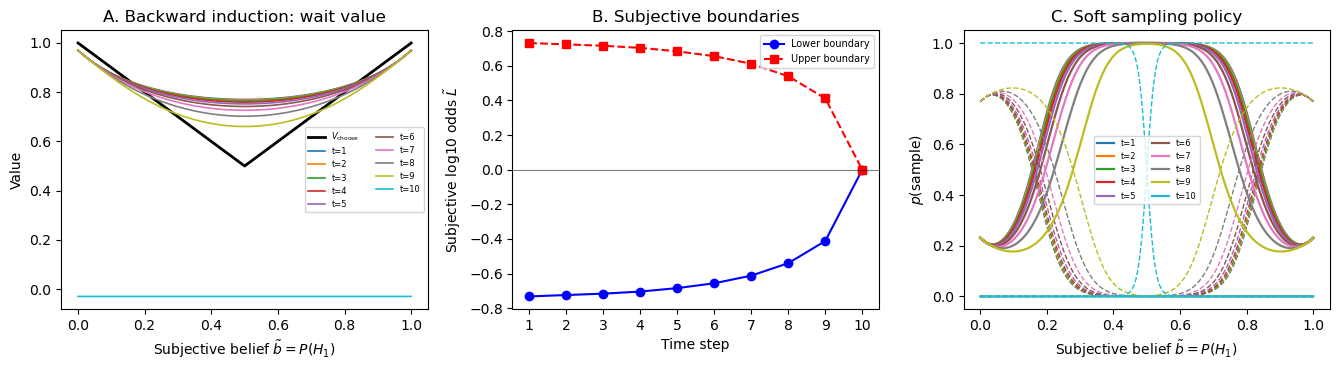

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# Mixed case, finite horizon:
# Noisy evidence representation + stochastic action execution
# ============================================================

# -----------------------------
# Main parameters
# -----------------------------

c = 0.03
sigma_repr = 0.25
tau_exec = 0.025

R_correct = 1.0
R_wrong = 0.0

T_deadline = 11
max_timestep = 10

n_trials = 5 * 10**4
rng = np.random.default_rng(1)

# ============================================================
# 1. Define 16 stimulus types and pA / pB
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Subjective log10-odds grid
# ============================================================

L_min = -4.0
L_max = 4.0
N_L = 2001

L_grid = np.linspace(L_min, L_max, N_L)

# Subjective belief from subjective log10 odds
b_grid = 1.0 / (1.0 + 10.0 ** (-L_grid))

Q0 = 1 - b_grid
Q1 = b_grid
V_choose = np.maximum(Q0, Q1)

# ============================================================
# 3. Helper functions
# ============================================================

def interp_value_L(L_query, L_grid, V):
    L_query = np.clip(L_query, L_grid[0], L_grid[-1])
    return np.interp(L_query, L_grid, V)

def softmax_3actions(Q0, Q1, QW, tau):
    """
    Softmax execution policy over:
        0 = choose H0
        1 = choose H1
        2 = sample / wait
    """
    Q_stack = np.vstack([Q0, Q1, QW]) / tau
    Q_stack = Q_stack - np.max(Q_stack, axis=0, keepdims=True)
    exp_Q = np.exp(Q_stack)
    return exp_Q / np.sum(exp_Q, axis=0, keepdims=True)

# Gauss-Hermite quadrature for representation noise
n_gh = 201
gh_x, gh_w = np.polynomial.hermite.hermgauss(n_gh)

noise_nodes = np.sqrt(2.0) * sigma_repr * gh_x
noise_weights = gh_w / np.sqrt(np.pi)

# ============================================================
# 4. Finite-horizon backward induction
#    Value estimation is independent of stochastic execution.
#    Terminal value: V[11, :] = 0
# ============================================================

V = np.zeros((T_deadline + 1, N_L))
Q_wait_all = np.zeros((T_deadline + 1, N_L))

policy_sample_hard = np.zeros((T_deadline + 1, N_L))

lower_L = np.full(T_deadline + 1, np.nan)
upper_L = np.full(T_deadline + 1, np.nan)

lower_b = np.full(T_deadline + 1, np.nan)
upper_b = np.full(T_deadline + 1, np.nan)

# Terminal deadline: no reward anywhere
V[T_deadline, :] = 0.0

# Backward induction: t = 10, 9, ..., 1
for t in range(T_deadline - 1, 0, -1):

    Q_wait = np.zeros_like(L_grid)

    for i, ell_i in enumerate(target_log_ratios):

        # Predictive probability according to subjective belief
        q_i = b_grid * pB[i] + (1 - b_grid) * pA[i]

        expected_over_noise = np.zeros_like(L_grid)

        for node, weight in zip(noise_nodes, noise_weights):

            L_next = L_grid + ell_i + node

            expected_over_noise += weight * interp_value_L(
                L_next,
                L_grid,
                V[t + 1, :]
            )

        Q_wait += q_i * expected_over_noise

    Q_wait = -c + Q_wait
    Q_wait_all[t, :] = Q_wait

    # Deterministic value backup
    # Execution stochasticity is applied after value estimation.
    V[t, :] = np.maximum(V_choose, Q_wait)

    continue_region = Q_wait > V_choose
    policy_sample_hard[t, :] = continue_region.astype(float)

    if np.any(continue_region):
        lower_L[t] = L_grid[continue_region][0]
        upper_L[t] = L_grid[continue_region][-1]
    else:
        lower_L[t] = 0.0
        upper_L[t] = 0.0

    lower_b[t] = 1.0 / (1.0 + 10.0 ** (-lower_L[t]))
    upper_b[t] = 1.0 / (1.0 + 10.0 ** (-upper_L[t]))

print(
    f"Finite-horizon mixed-noise observer: "
    f"sigma_repr={sigma_repr}, tau_exec={tau_exec}"
)

for t in range(1, max_timestep + 1):
    print(
        f"t={t:2d}: "
        f"lower_L={lower_L[t]: .3f}, upper_L={upper_L[t]: .3f}, "
        f"lower_b={lower_b[t]: .3f}, upper_b={upper_b[t]: .3f}"
    )

# ============================================================
# 5. Soft execution policy over time
# ============================================================

p_choose0_all = np.zeros((T_deadline + 1, N_L))
p_choose1_all = np.zeros((T_deadline + 1, N_L))
p_sample_all = np.zeros((T_deadline + 1, N_L))

for t in range(1, max_timestep + 1):

    probs_t = softmax_3actions(
        Q0,
        Q1,
        Q_wait_all[t, :],
        tau_exec
    )

    p_choose0_all[t, :] = probs_t[0, :]
    p_choose1_all[t, :] = probs_t[1, :]
    p_sample_all[t, :] = probs_t[2, :]

# ============================================================
# 6. Panel A/B/C summary figure
# ============================================================

time_colors = plt.cm.tab10(np.arange(max_timestep))
t_grid = np.arange(1, max_timestep + 1)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axA, axB, axC = axes

# -----------------------------
# Panel A: V_choose and V_wait over time
# -----------------------------

axA.plot(
    b_grid,
    V_choose,
    color="black",
    linewidth=2,
    label=r"$V_{\mathrm{choose}}$"
)

for t in range(1, max_timestep + 1):
    axA.plot(
        b_grid,
        Q_wait_all[t, :],
        color=time_colors[t - 1],
        linewidth=1.2,
        label=f"t={t}"
    )

axA.set_xlabel(r"Subjective belief $\tilde b=P(H_1)$")
axA.set_ylabel("Value")
axA.set_title("A. Backward induction: wait value")
axA.legend(fontsize=6, ncol=2, frameon=True)

# -----------------------------
# Panel B: hard indifference boundaries over time
# -----------------------------

axB.plot(
    t_grid,
    lower_L[1:max_timestep + 1],
    marker="o",
    color="blue",
    label="Lower boundary"
)

axB.plot(
    t_grid,
    upper_L[1:max_timestep + 1],
    marker="s",
    linestyle="--",
    color="red",
    label="Upper boundary"
)

axB.axhline(0, color="black", linewidth=0.8, alpha=0.5)

axB.set_xlabel("Time step")
axB.set_ylabel(r"Subjective log10 odds $\tilde L$")
axB.set_xticks(t_grid)
axB.set_title("B. Subjective boundaries")
axB.legend(fontsize=7, frameon=True)

# -----------------------------
# Panel C: soft p(sample) over subjective belief
# -----------------------------

for t in range(1, max_timestep + 1):
    axC.plot(
        b_grid,
        p_sample_all[t, :],
        color=time_colors[t - 1],
        linewidth=1.6,
        label=f"t={t}"
    )
    axC.plot(
        b_grid,
        p_choose0_all[t, :],
        color=time_colors[t - 1],
        linewidth=1,
        linestyle="--",
    )
    axC.plot(
        b_grid,
        p_choose1_all[t, :],
        color=time_colors[t - 1],
        linewidth=1,
        linestyle="--",
    )

axC.set_xlabel(r"Subjective belief $\tilde b=P(H_1)$")
axC.set_ylabel(r"$p(\mathrm{sample})$")
axC.set_ylim(-0.05, 1.05)
axC.set_title("C. Soft sampling policy")
axC.legend(fontsize=6, ncol=2, frameon=True)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 7. Simulate 5*10^4 trials
# ============================================================

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)  # 0 = H0/A, 1 = H1/B

    L_true = 0.0
    L_subj = 0.0

    for t in range(1, max_timestep + 1):

        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        ell = target_log_ratios[stim_idx]

        # Ground-truth posterior log10 odds
        L_true += ell

        # Subjective noisy representation with perfect integration
        L_subj += ell + rng.normal(0.0, sigma_repr)

        b_true = 1.0 / (1.0 + 10.0 ** (-L_true))
        b_subj = 1.0 / (1.0 + 10.0 ** (-L_subj))

        q0_t = np.interp(L_subj, L_grid, Q0)
        q1_t = np.interp(L_subj, L_grid, Q1)
        qw_t = np.interp(L_subj, L_grid, Q_wait_all[t, :])

        probs_t = softmax_3actions(
            np.array([q0_t]),
            np.array([q1_t]),
            np.array([qw_t]),
            tau_exec
        ).flatten()

        action = rng.choice([0, 1, 2], p=probs_t)

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "ground_L": L_true,
            "subjective_L": L_subj,
            "ground_b": b_true,
            "subjective_b": b_subj,
            "action": action,
            "p_choose0": probs_t[0],
            "p_choose1": probs_t[1],
            "p_sample": probs_t[2]
        })

        # Stop trial after executed choice.
        # If action == 2 at t=10, the trial reaches the t=11 deadline.
        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

   trial  true_H  time_step  stim_idx  ground_L  subjective_L  ground_b  \
0      0       0          1        12       0.5      0.582609  0.759747   
1      0       0          2         4       0.1      0.294203  0.557312   
2      0       0          3         5      -0.2      0.085346  0.386863   
3      0       0          4         8      -0.1      0.322024  0.442688   
4      0       0          5         9       0.1      0.401494  0.557312   

   subjective_b  action     p_choose0  p_choose1  p_sample  
0      0.792738       2  1.635329e-11   0.242283  0.757717  
1      0.663164       2  1.770283e-08   0.008259  0.991741  
2      0.548972       2  3.405224e-06   0.000171  0.999825  
3      0.677321       2  1.178839e-08   0.017069  0.982931  
4      0.715953       2  2.000089e-09   0.063679  0.936321  
action
2    142296
0     25093
1     24907
Name: count, dtype: int64


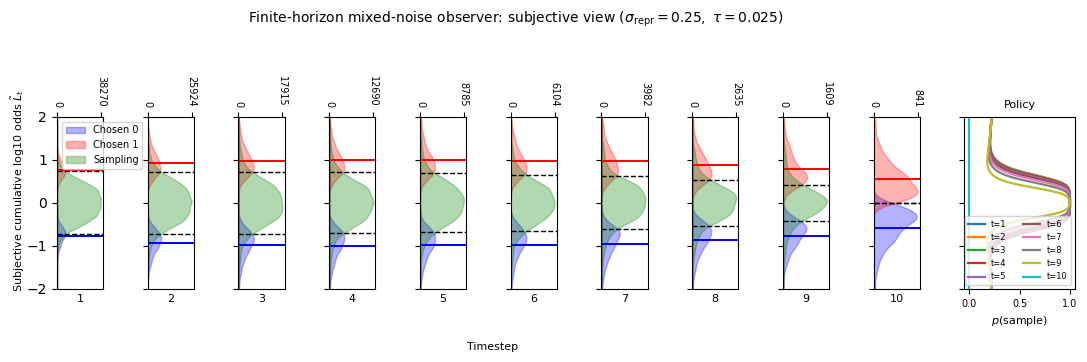

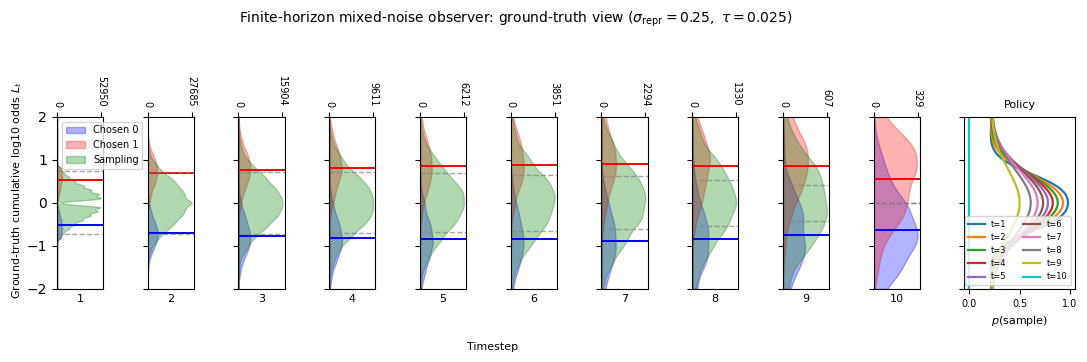

In [23]:
# ============================================================
# 8. Policy helper functions
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green"
}

labels = {
    0: "Chosen 0",
    1: "Chosen 1",
    2: "Sampling"
}

def empirical_policy_by_bins(
    df,
    y_col,
    y_min,
    y_max,
    n_bins=60,
    min_count=10
):
    bins = np.linspace(y_min, y_max, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    out = {}

    for t in range(1, max_timestep + 1):

        dft = df[df["time_step"] == t]

        y = dft[y_col].to_numpy()
        is_sample = (dft["action"] == 2).astype(float).to_numpy()

        p_emp = np.full_like(centers, np.nan, dtype=float)

        for k in range(n_bins):
            mask = (y >= bins[k]) & (y < bins[k + 1])

            if mask.sum() >= min_count:
                p_emp[k] = is_sample[mask].mean()

        out[t] = p_emp

    return centers, out


def p_sample_ground_view(y_grid, t):
    """
    Ground-truth view:
    p(sample | L_true, t)

    Since:
        L_subj = L_true + accumulated representation noise

    and accumulated representation noise has std:
        sigma_repr * sqrt(t)

    this averages the subjective soft policy over that noise.
    """

    s_t = sigma_repr * np.sqrt(t)

    nodes_t = np.sqrt(2.0) * s_t * gh_x
    weights_t = gh_w / np.sqrt(np.pi)

    p_out = np.zeros_like(y_grid)

    for node, weight in zip(nodes_t, weights_t):

        p_out += weight * np.interp(
            y_grid + node,
            L_grid,
            p_sample_all[t, :],
            left=p_sample_all[t, 0],
            right=p_sample_all[t, -1]
        )

    return p_out

# ============================================================
# 9. Main plotting function: subjective view and ground-truth view
# ============================================================

def plot_mixed_finite_view(
    df,
    y_col,
    y_label,
    title,
    ground_truth_view=False
):

    fig, axes = plt.subplots(
        1,
        max_timestep + 1,
        figsize=(11.5, 3.4),
        sharey=True,
        gridspec_kw={"width_ratios": [1] * max_timestep + [2.4]}
    )

    dist_axes = axes[:-1]
    policy_ax = axes[-1]

    y_min = -2
    y_max = 2
    y_grid = np.linspace(y_min, y_max, 500)

    # ------------------------------------------------------------
    # Left panels: distributions + dark p(sample) shadow
    # ------------------------------------------------------------

    for t in range(1, max_timestep + 1):

        ax = dist_axes[t - 1]
        timestep_data = df[df["time_step"] == t]

        max_density = 0.0

        if ground_truth_view:
            p_sample_y = p_sample_ground_view(y_grid, t)
        else:
            p_sample_y = np.interp(
                y_grid,
                L_grid,
                p_sample_all[t, :],
                left=p_sample_all[t, 0],
                right=p_sample_all[t, -1]
            )
        """
        # Dark shadow: larger p(sample) = darker
        for k in range(len(y_grid) - 1):
            alpha_k = 1 - p_sample_y[k]

            if alpha_k > 0.003:
                ax.axhspan(
                    y_grid[k],
                    y_grid[k + 1],
                    color="black",
                    alpha=alpha_k,
                    linewidth=0
                )
        """

        # Empirical distributions
        for action in [0, 1, 2]:

            action_data = timestep_data[timestep_data["action"] == action]

            if action_data.empty:
                continue

            ev = action_data[y_col].to_numpy()

            if len(ev) < 3 or np.std(ev) == 0:
                continue

            kde = gaussian_kde(ev)
            density = kde(y_grid)

            density_scaled = density * len(ev)
            max_density = max(max_density, density_scaled.max())

            ax.fill_betweenx(
                y_grid,
                0,
                density_scaled,
                color=colors[action],
                alpha=0.3,
                label=labels[action] if t == 1 else None
            )

            if action in [0, 1]:
                mean_ev = np.mean(ev)

                ax.axhline(
                    mean_ev,
                    color=colors[action],
                    linewidth=1.4
                )

        if t == 1:
            ax.legend(loc="upper left", fontsize=7, frameon=True)

        # Hard indifference boundaries from subjective DP.
        # In the ground-truth view, these are only faint reference centers.
        ax.axhline(
            lower_L[t],
            color="black" if not ground_truth_view else "gray",
            linestyle="--",
            linewidth=1,
            alpha=1.0 if not ground_truth_view else 0.7
        )

        ax.axhline(
            upper_L[t],
            color="black" if not ground_truth_view else "gray",
            linestyle="--",
            linewidth=1,
            alpha=1.0 if not ground_truth_view else 0.7
        )

        ax.set_ylim(y_min, y_max)

        if max_density > 0:
            ax.set_xlim(0, max_density * 1.05)
            ax.set_xticks([0, int(max_density)])
        else:
            ax.set_xlim(0, 1)
            ax.set_xticks([0, 1])

        ax.xaxis.set_ticks_position("top")
        ax.tick_params(
            axis="x",
            top=True,
            labeltop=True,
            labelbottom=False
        )

        ax.set_xticklabels(
            [str(int(x)) for x in ax.get_xticks()],
            rotation=270,
            fontsize=7
        )

        ax.set_xlabel(str(t), fontsize=8)

    # ------------------------------------------------------------
    # Right panel: p(sample) policy curves
    # ------------------------------------------------------------

    centers, empirical_policy = empirical_policy_by_bins(
        df,
        y_col=y_col,
        y_min=y_min,
        y_max=y_max,
        n_bins=60,
        min_count=10
    )

    for t in range(1, max_timestep + 1):

        color_t = time_colors[t - 1]

        if ground_truth_view:
            p_sample_y = p_sample_ground_view(y_grid, t)
        else:
            p_sample_y = np.interp(
                y_grid,
                L_grid,
                p_sample_all[t, :],
                left=p_sample_all[t, 0],
                right=p_sample_all[t, -1]
            )

        # Optimal soft policy
        policy_ax.plot(
            p_sample_y,
            y_grid,
            color=color_t,
            linewidth=1.6,
            label=f"t={t}"
        )
        """
        # Empirical p(sample)
        policy_ax.plot(
            empirical_policy[t],
            centers,
            color=color_t,
            linestyle="--",
            linewidth=1.1,
            alpha=0.85
        )
        """

    policy_ax.set_xlim(-0.05, 1.05)
    policy_ax.set_xticks([0, 0.5, 1.0])
    policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
    policy_ax.set_title("Policy", fontsize=8)
    policy_ax.tick_params(axis="x", labelsize=7)

    policy_ax.legend(
        loc="lower right",
        fontsize=6,
        ncol=2,
        frameon=True
    )

    fig.text(
        0.48,
        0.03,
        "Timestep",
        ha="center",
        fontsize=8
    )

    fig.text(
        0.06,
        0.5,
        y_label,
        va="center",
        rotation="vertical",
        fontsize=8
    )

    fig.suptitle(title, fontsize=10, y=1.03)

    for ax in dist_axes:
        ax.label_outer()

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
    plt.show()

# ============================================================
# 10A. Subjective view
# ============================================================

plot_mixed_finite_view(
    df=df_sim,
    y_col="subjective_L",
    y_label=r"Subjective cumulative log10 odds $\tilde L_t$",
    title=(
        "Finite-horizon mixed-noise observer: subjective view "
        r"$(\sigma_{\mathrm{repr}}=0.25,\ \tau=0.025)$"
    ),
    ground_truth_view=False
)

# ============================================================
# 10B. Ground-truth view
# ============================================================

plot_mixed_finite_view(
    df=df_sim,
    y_col="ground_L",
    y_label=r"Ground-truth cumulative log10 odds $L_t$",
    title=(
        "Finite-horizon mixed-noise observer: ground-truth view "
        r"$(\sigma_{\mathrm{repr}}=0.25,\ \tau=0.025)$"
    ),
    ground_truth_view=True
)